# **Screen Time and Mental Health: A Data-Driven Study**
* **Course:** Data Science Programming (D7054E) - Group 22
* **Members:** Carlos González Mendoza and Fatima Juairiah
* **Dataset source:** https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025

## Data Understanding and Preparation

### Dataset import and overview

In [ ]:
# Standard library
import os

# Third-party libraries (data handling)
import numpy as np
import pandas as pd

# Dataset download
import kagglehub

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Download the dataset from Kaggle and store the local path
path = kagglehub.dataset_download(
    "adharshinikumar/screentime-vs-mentalwellness-survey-2025"
)

# List all files in the downloaded directory
files = os.listdir(path)

# Automatically find the first CSV file in the directory
csv_file = [file for file in files if file.endswith(".csv")][0]

# Build the full file path and load the dataset into a DataFrame
df = pd.read_csv(os.path.join(path, csv_file))

# Display the first rows of the dataset
df.head(3)

Using Colab cache for faster access to the 'screentime-vs-mentalwellness-survey-2025' dataset.


,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

### Data cleaning and formatting

In [ ]:
# Check for nulls and duplicated rows
print(df.isnull().sum().sum())
print(df.duplicated().sum())

400
0


In [ ]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Remove empty columns ("Unnamed")
df = df.loc[:, ~df.columns.str.contains("^unnamed", case=False)]

df.head(3)

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6


In [ ]:
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicated rows:", df.duplicated().sum())

Dataset shape: (400, 15)
Total missing values: 0
Duplicated rows: 0


In [ ]:
df.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000


In [ ]:
# Remove id
df = df.drop(columns=["user_id"])

# Split types
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours',
       'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10',
       'productivity_0_100', 'exercise_minutes_per_week',
       'social_hours_per_week', 'mental_wellness_index_0_100'],
      dtype='object')
Categorical: Index(['gender', 'occupation', 'work_mode'], dtype='object')


Check variable consistency. Ideally, it should be close to 0.

In [ ]:
diff = df['screen_time_hours'] - (
    df['work_screen_hours'] + df['leisure_screen_hours']
)

print("Max difference:", diff.abs().max())
print("Rows with inconsistent values:", (~np.isclose(diff, 0)).sum())

Max difference: 3.552713678800501e-15
Rows with inconsistent values: 0


### Correlation between numerical variables
We explore the relationships between digital device use, sleep patterns, and well-being indicators to identify potential predictive variables and behavioral patterns.

**📌 Initial hypotheses:**
* More screen time → poorer sleep
* Less sleep → more stress
* More stress → lower productivity
* Less mental wellness → lower productivity

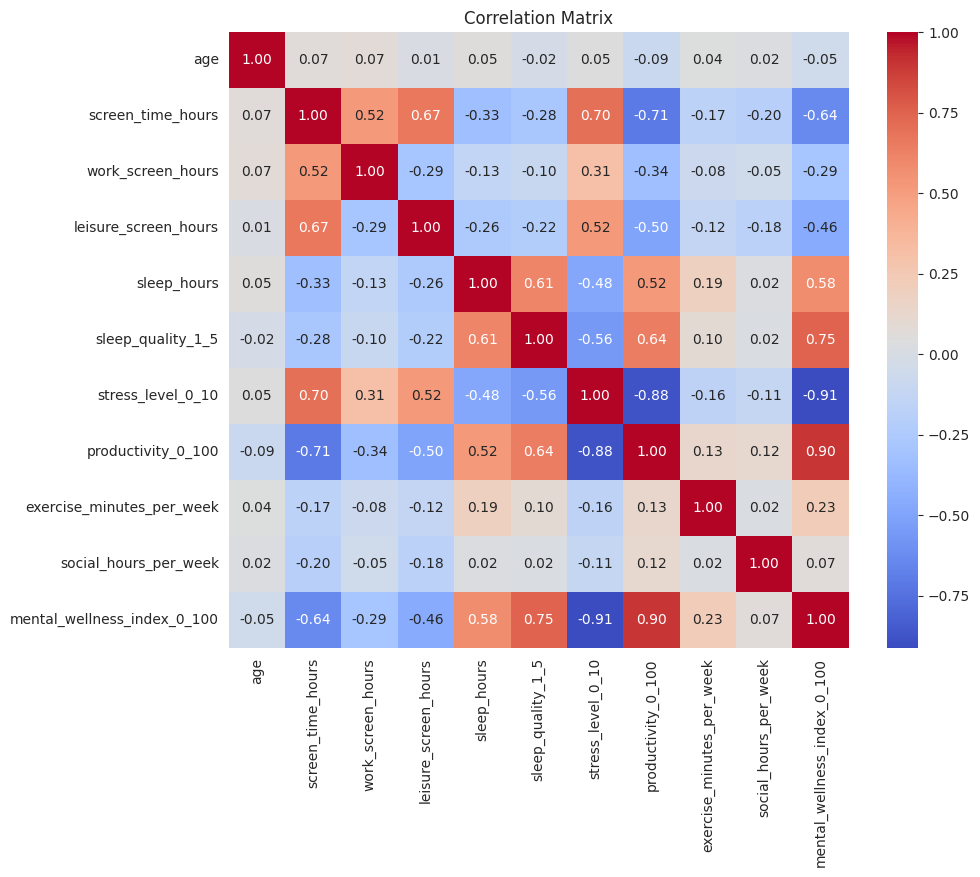

In [ ]:
# Study the correlation between numerical features
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Key relationships between variables

**Hypotheses:**
* **Do screen time hours affect people’s sleep duration?**
* **Does a high level of stress lead to shorter sleep duration?**
* **Does stress affect reported productivity?**
* **Is mental wellness a clear indicator of lower productivity?**

#### Screen time vs Sleep

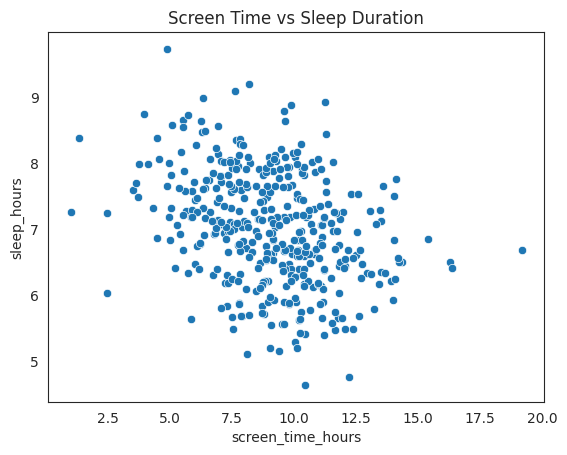

In [ ]:
sns.scatterplot(data=df, x='screen_time_hours', y='sleep_hours')

plt.title("Screen Time vs Sleep Duration")
plt.show()

🔎 **Observation:** correlation ≈ -0.33

The scatterplot shows a moderate negative relationship between screen time and sleep duration. Most observations are concentrated around the center of the distribution, with some dispersion. There is a slight downward trend, suggesting that individuals who spend more hours in front of screens tend to sleep slightly fewer hours on average.

#### Sleep vs Stress

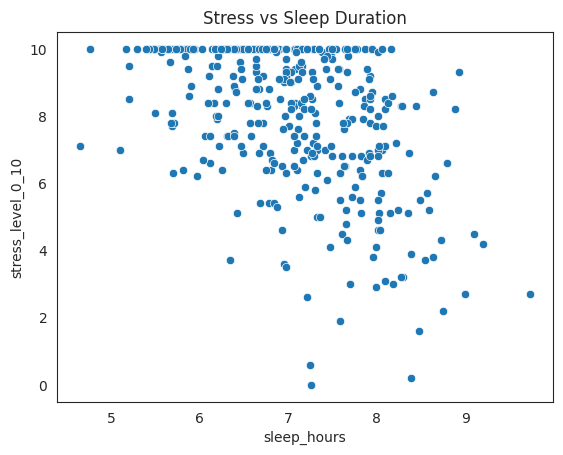

In [ ]:
sns.scatterplot(data=df, x='sleep_hours', y='stress_level_0_10')

plt.title("Stress vs Sleep Duration")
plt.show()

🔎 **Observation:** correlation ≈ -0.48

The scatterplot suggests a moderate negative relationship between sleep duration and stress levels. While the data points are relatively dispersed, there is a general tendency for individuals who sleep fewer hours to report higher stress levels. A notable concentration of observations appears at the highest stress level (10), where average sleep duration ranges roughly between 5 and 8 hours per night.

#### Stress vs Productivity

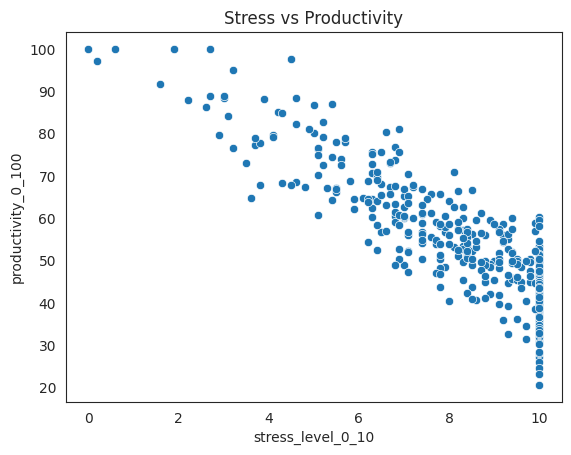

In [ ]:
sns.scatterplot(data=df, x='stress_level_0_10', y='productivity_0_100')

plt.title("Stress vs Productivity")
plt.show()

🔎 **Observation:** correlation ≈ -0.88

A strong negative correlation is observed between stress level and productivity. The points form a clear downward diagonal pattern, indicating that higher stress levels are associated with lower productivity scores. Additionally, there is a noticeable concentration of observations at the maximum stress level (10), where productivity values vary widely, ranging roughly from 20 to around 60. This suggests that a large number of individuals in the dataset report very high stress levels, though their productivity outcomes still vary.

#### Mental Wellness vs Productivity

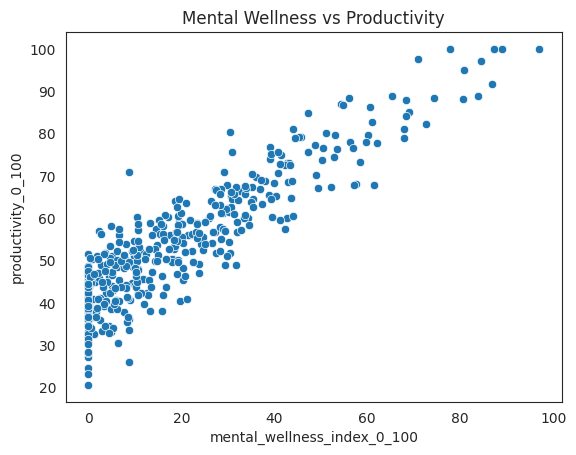

In [ ]:
sns.scatterplot(data=df, x='mental_wellness_index_0_100', y='productivity_0_100')

plt.title("Mental Wellness vs Productivity")
plt.show()

🔎 **Observation:** correlation ≈ 0.90

A strong positive correlation is observed between mental wellness and productivity, with a clear upward trend indicating that higher mental wellness is associated with higher productivity. There is also a notable concentration of points in the lower-left area, particularly at very low mental wellness levels (around 0–50), where productivity is also low. This suggests that a significant portion of individuals in the dataset experience poor mental wellness, which is consistently associated with lower productivity outcomes.

### Analyzing categorical vs. continuous variables

**Hypotheses:**
* **Does productivity depend on the work/study mode? We expect that in-person settings are generally associated with higher productivity.**

#### Box plot of productivity by work_mode

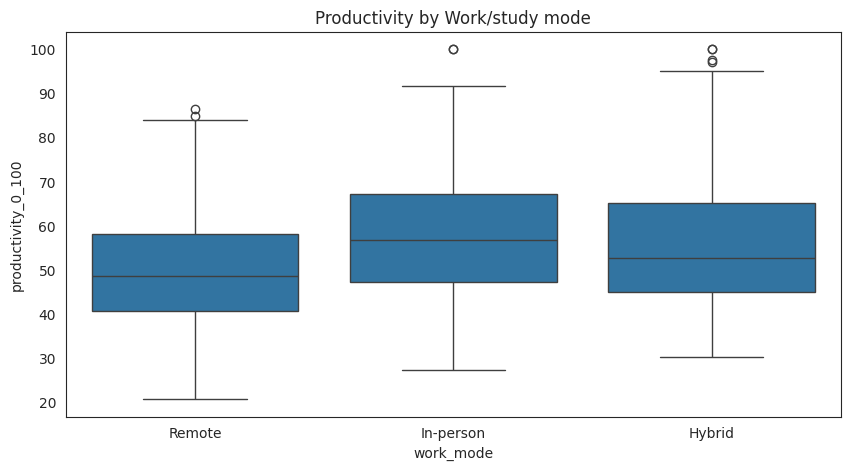

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='work_mode', y='productivity_0_100')

plt.title("Productivity by Work/study mode")
plt.show()

🔎 The boxplot compares productivity distributions across different work modes (Remote, In-person, and Hybrid). All three categories display upper outliers, indicating some individuals achieve exceptionally high productivity scores.

* The **Remote** group shows a relatively symmetric distribution with a slight positive skew and a somewhat concentrated distribution around the median.

* The **In-person** group appears similarly balanced but with slightly less concentration around the center. This group also contains the most pronounced outlier, clearly separated from the upper range of the data.

* The **Hybrid** group shows a more noticeable positive skew, with the median positioned closer to the first quartile (Q1). Overall, the distribution remains fairly balanced, suggesting that productivity levels are relatively comparable across work modes, although variability exists.

### Feature Engineering
1️⃣ **Work / Leisure ratio:** distinguishes people who use screens more for work than for leisure.
* < 1  → Screen time is primarily used for leisure
* = 1  → Balanced use between work and leisure
* \> 1  → Screen time is primarily used for work

(+1 to avoid creating extreme outliers and dividing by 0)

In [ ]:
df['work_leisure_ratio'] = df['work_screen_hours'] / (df['leisure_screen_hours'] + 1)

2️⃣ **Lifestyle balance score:** combines average hours of sleep, hours of exercise, and social hours to calculate a lifestyle score.

* "exercise" and "social_hours" do not have a fixed scale.

In [ ]:
df['lifestyle_score'] = (
    (df['exercise_minutes_per_week'] / df['exercise_minutes_per_week'].max()) * 0.4 +
    (df['social_hours_per_week'] / df['social_hours_per_week'].max()) * 0.2 +
    (df['sleep_quality_1_5'] / 5) * 0.4
) * 100

3️⃣ **Digital overload:** captures the relationship between digital use and stress.

In [ ]:
df['digital_overload'] = df['screen_time_hours'] * df['stress_level_0_10']

4️⃣ **Sleep efficiency proxy:** summarizes sleep health.

In [ ]:
df['sleep_health_score'] = (
    (df['sleep_hours'] / df['sleep_hours'].max()) * 0.5 +
    (df['sleep_quality_1_5'] / 5) * 0.5
) * 100

In [ ]:
# Update numerical columns after Feature Engineering
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

### New correlation matrix with created features
This allows us to determine whether the new variables are more strongly associated with productivity or mental wellness.

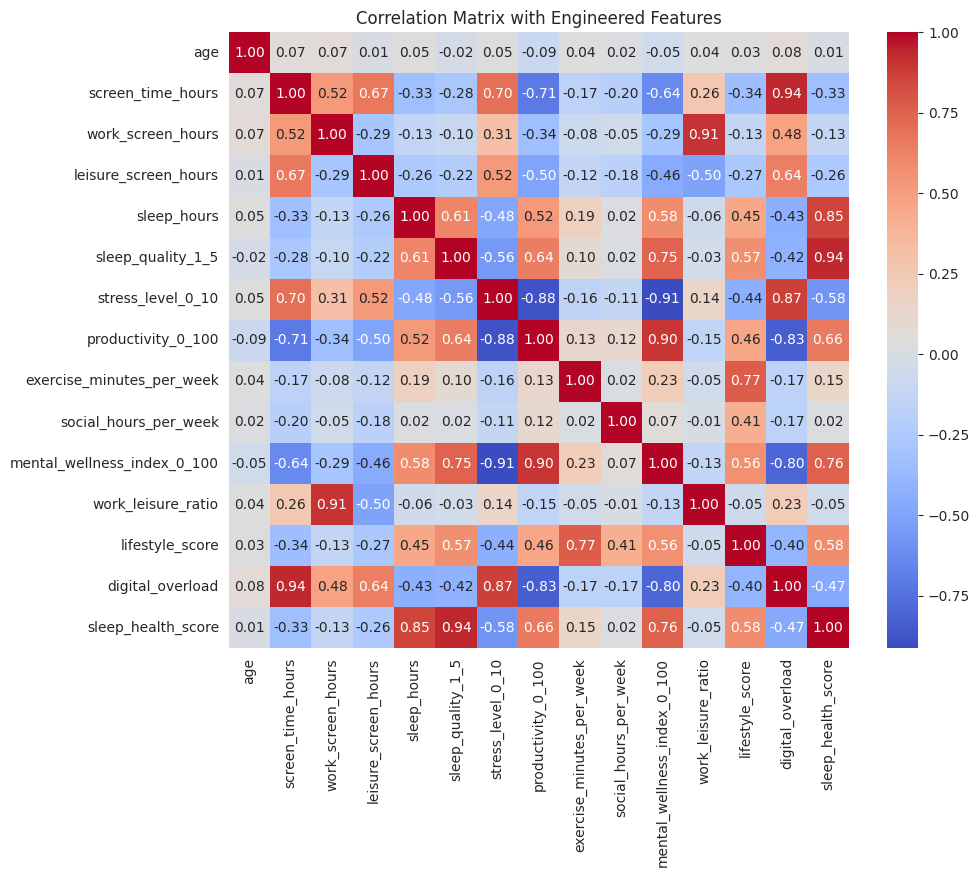

In [ ]:
# Study the correlation between numerical features (now with Engineered Features)
plt.figure(figsize=(10,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix with Engineered Features")
plt.show()

### Correlation with productivity

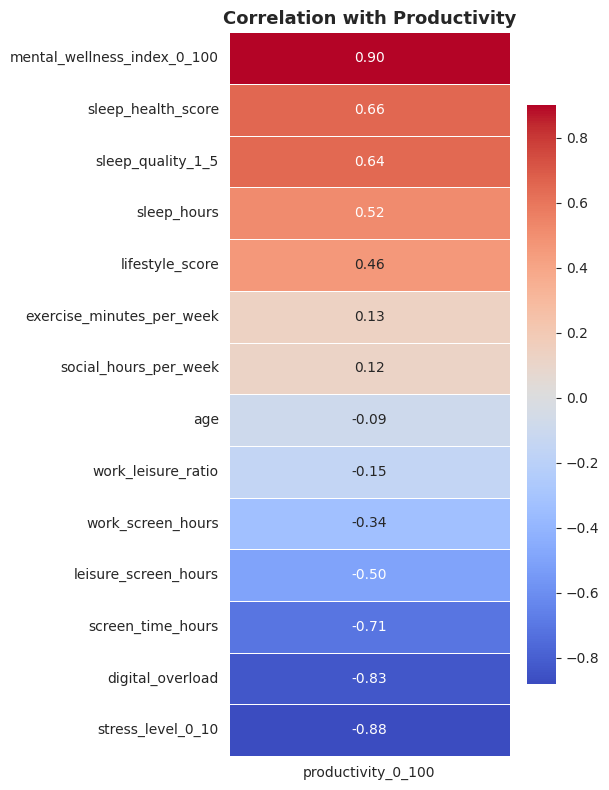

In [ ]:
sns.set_style("white")

# Correlation with productivity
corr_productivity = (
    df[num_cols]
    .corr()[["productivity_0_100"]]
    .drop(index="productivity_0_100")   # remove self-correlation
    .sort_values(by="productivity_0_100", ascending=False)
)

# Plot
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_productivity,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation with Productivity", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

### Correlation with mental wellness

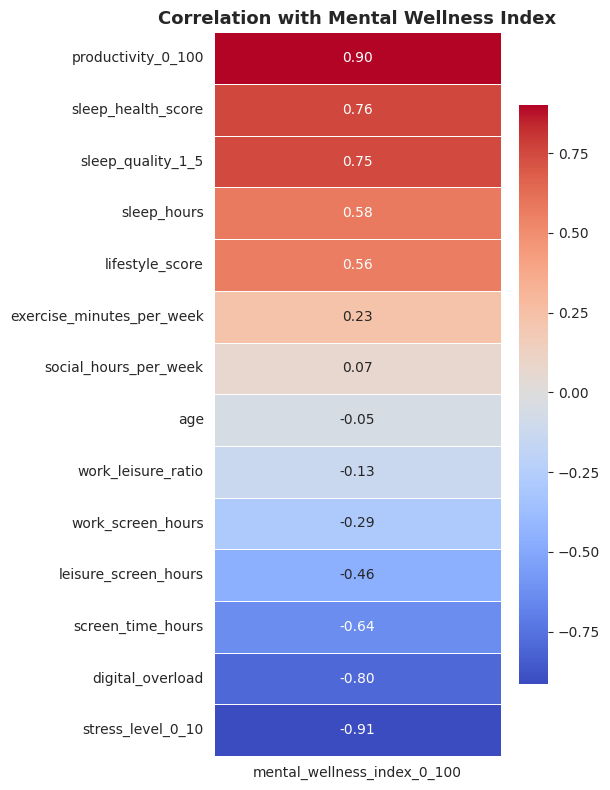

In [ ]:
sns.set_style("white")

# Correlation with mental wellness
corr_mental_wellness = (
    df[num_cols]
    .corr()[["mental_wellness_index_0_100"]]
    .drop(index="mental_wellness_index_0_100")  # remove self-correlation
    .sort_values(by="mental_wellness_index_0_100", ascending=False)
)

# Plot
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_mental_wellness,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation with Mental Wellness Index", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

## Modeling - Productivity Prediction
### 1️⃣ Prepare the data

In [ ]:
# Copy of the dataset
df_model = df.copy()

# Target variable
y = df_model['productivity_0_100']

# Remove target from dataset
X = df_model.drop(columns=['productivity_0_100'])

#### One-Hot Encoding of categorical variables
* Convert categorical variable into dummy/indicator variables.
* Each variable is converted in as many 0/1 variables as there are different values. Columns in the output are each named after a value; if the input is a DataFrame, the name of the original variable is prepended to the value.

In [ ]:
X = pd.get_dummies(X, drop_first=True)

### 2️⃣ Train / Test Split



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3️⃣ Scaling (for linear models only)
Linear regression performs better with scaled variables.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4️⃣ Model 1 - Linear Regression

* MAE → mean absolute error in productivity points
* RMSE → penalizes larger errors more heavily
* R² → % of explained variance

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("LINEAR REGRESSION RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

LINEAR REGRESSION RESULTS
MAE: 4.353505612709887
RMSE: 5.5848101026215975
R2: 0.8349357412453345


#### This time using Gradient Descent (SGDRegressor)

In [ ]:
sgd = SGDRegressor(
    loss='squared_error',      # Linear regression loss (MSE)
    penalty='l2',              # L2 regularization (Ridge)
    alpha=0.0001,              # Regularization strength
    learning_rate='adaptive',  # Decrease LR if no improvement
    eta0=0.01,                 # Initial learning rate
    max_iter=5000,             # Maximum number of iterations
    early_stopping=True,       # Stop early if validation score stops improving
    validation_fraction=0.1,   # Fraction of data used for validation
    n_iter_no_change=20,       # Tolerance for early stopping
    random_state=42            # Reproducibility
)

# Train the model
sgd.fit(X_train_scaled, y_train)

# Generate predictions on test set
y_pred_sgd = sgd.predict(X_test_scaled)

# Evaluate model performance
print("SGD REGRESSOR RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_sgd))  # Mean Absolute Error
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sgd)))  # Root MSE
print("R2:", r2_score(y_test, y_pred_sgd))  # R-squared score

SGD REGRESSOR RESULTS
MAE: 4.427653941226297
RMSE: 5.642731398170363
R2: 0.8314941510078373


Linear Regression outperforms SGD on all three metrics, although the difference is small (the models are quite similar in performance).

### 5️⃣ Model 2 - Random Forest Regressor
(No scaling required)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))


RANDOM FOREST RESULTS
MAE: 4.926123141464653
RMSE: 6.317549709502238
R2: 0.7887807187592739


### 6️⃣ Model 3 - Gradient Boosting Regressor

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("\nGRADIENT BOOSTING RESULTS")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2:", r2_score(y_test, y_pred_gb))


GRADIENT BOOSTING RESULTS
MAE: 5.312602816703115
RMSE: 6.8398281151830504
R2: 0.75241370503628


### 7️⃣ Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
0,Linear Regression,4.353506,5.584810,0.834936
1,Random Forest,4.926123,6.317550,0.788781
2,Gradient Boosting,5.312603,6.839828,0.752414


🔎 **Linear Regression achieved the best performance among the evaluated models (R² = 0.835), outperforming Random Forest and Gradient Boosting.** This suggests that productivity is largely driven by linear relationships with behavioral and wellness variables.

Ensemble methods did not improve predictive accuracy, indicating limited non-linear structure in the data or possible overfitting due to the relatively small dataset size (n = 400).

### 8️⃣ Feature Importance
Random Forest Importance

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

,0
mental_wellness_index_0_100,0.740733
stress_level_0_10,0.074478
digital_overload,0.068389
screen_time_hours,0.021796
age,0.012962
exercise_minutes_per_week,0.012849
lifestyle_score,0.010782
social_hours_per_week,0.010668
leisure_screen_hours,0.009860
sleep_health_score,0.008767


<Axes: >

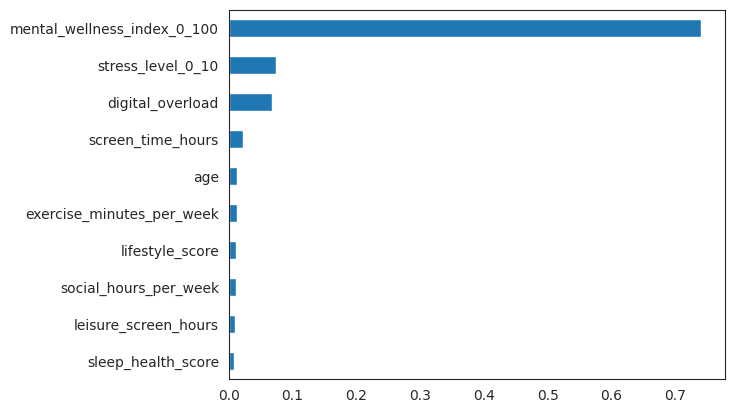

In [ ]:
# Visualization
importances.sort_values().tail(10).plot(kind='barh')

🔎 Random Forest feature importance shows that the mental wellness index is by far the strongest predictor of productivity, accounting for most of the model’s explanatory power. Stress level and digital overload indicators also contribute, confirming the strong relationship between psychological well-being, digital habits, and performance.

⚠️ *mental_wellness_index_0_100* predicts productivity extremely strongly.
* It is possible that, since both variables are self-reported in the survey, individuals who feel mentally well also perceive themselves as productive. Therefore, the model may be capturing a similar subjective perception rather than true causality.


### Pred vs Real Plot
#### Linear Regression

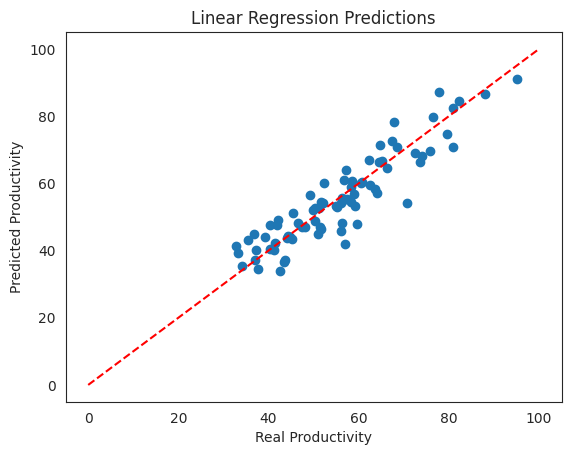

In [ ]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Real Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Linear Regression Predictions")
plt.plot([0,100],[0,100],'r--')
plt.show()

#### Random Forest

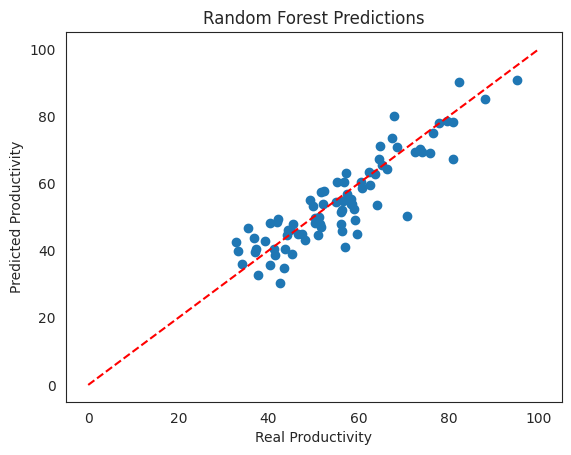

In [ ]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Real Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Random Forest Predictions")
plt.plot([0,100],[0,100],'r--')
plt.show()

#### Gradient Boosting

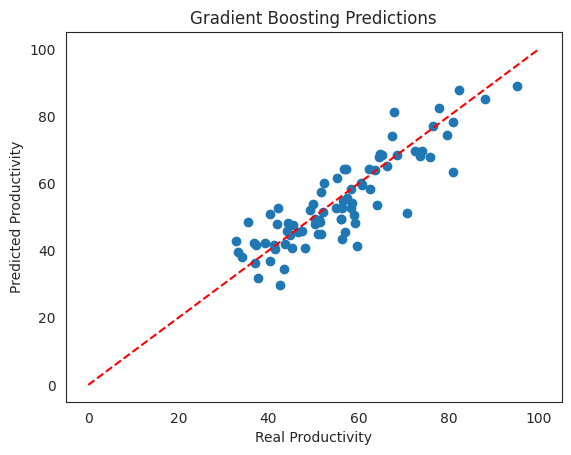

In [ ]:
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Real Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Gradient Boosting Predictions")
plt.plot([0,100],[0,100],'r--')
plt.show()

#### Prediction comparison
🔎 The Linear Regression predictions align more closely with the ideal diagonal line, indicating better calibration and smaller prediction errors. Tree-based models show slightly greater dispersion, especially for extreme productivity values.

## Stress Modeling

objective is to model stress levels using smartphone usage or screen time and lifestyle factors.


*Descriptive Features Considering*

screen_time_hours

work_screen_hours

leisure_screen_hours

sleep_hours

exercise_minutes_per_week

social_hours_per_week


*Target Feature*

stress_level_0_10

In [ ]:
print(df.columns.tolist())

['age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100', 'work_leisure_ratio', 'lifestyle_score', 'digital_overload', 'sleep_health_score']


In [ ]:
y = df['stress_level_0_10']

X = df[[
    'screen_time_hours',
    'work_screen_hours',
    'leisure_screen_hours',
    'sleep_hours',
    'exercise_minutes_per_week',
    'social_hours_per_week'
]]

Derived Feature

In [ ]:
df['screen_sleep_ratio'] = df['screen_time_hours'] / df['sleep_hours']

In [ ]:
X = df[[
    'screen_time_hours',
    'work_screen_hours',
    'leisure_screen_hours',
    'sleep_hours',
    'exercise_minutes_per_week',
    'social_hours_per_week',
    'screen_sleep_ratio'
]]

**Stress Modeling - Model 1**

**Random Forest**

In [ ]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)  # RMSE = sqrt(MSE)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance)


Random Forest Regressor
MAE: 1.1755437500000003
RMSE: 1.578715729042123
R2: 0.4024268024228107

Feature Importance (Random Forest):
                     feature  importance
6         screen_sleep_ratio    0.673909
3                sleep_hours    0.072966
0          screen_time_hours    0.071034
1          work_screen_hours    0.050924
4  exercise_minutes_per_week    0.049741
5      social_hours_per_week    0.043172
2       leisure_screen_hours    0.038253


**Stress Modeling - Model 2**

**Support Vector Regressor (SVR)**

In [ ]:
# Support Vector Regressor (needs scaling)
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

svr_pipeline.fit(X_train, y_train)
y_pred_svr = svr_pipeline.predict(X_test)


mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nSupport Vector Regressor")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)


Support Vector Regressor
MAE: 1.173908869031043
RMSE: 1.5374461521566558
R2: 0.43326104362347373


In [ ]:
# Tuned SVR
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear'))
])

svr_pipeline.fit(X_train, y_train)
y_pred_svr = svr_pipeline.predict(X_test)


mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nSupport Vector Regressor")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)



Support Vector Regressor
MAE: 1.222829141939564
RMSE: 1.4838857845751114
R2: 0.47206046318391814


Result Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVR'],
    'MAE': [mae, mae_svr],
    'RMSE': [rmse, rmse_svr],
    'R2 Score': [r2, r2_svr]
})

print(results)

           Model       MAE      RMSE  R2 Score
0  Random Forest  1.175544  1.578716  0.402427
1            SVR  1.222829  1.483886  0.472060


SVR performs well in this context as it is effective in handling high-dimensional data and can model complex relationships between behavioral features and stress levels. Its ability to control overfitting through margin optimization makes it suitable for behavioral data with potential noise and variability.

**Find average stress level per occupation**

In [ ]:
stress_by_occ = df.groupby('occupation')['stress_level_0_10'].mean().sort_values(ascending=False)

print(stress_by_occ)

occupation
Student          8.733645
Employed         8.214493
Self-employed    7.953333
Retired          6.635714
Unemployed       6.462963
Name: stress_level_0_10, dtype: float64


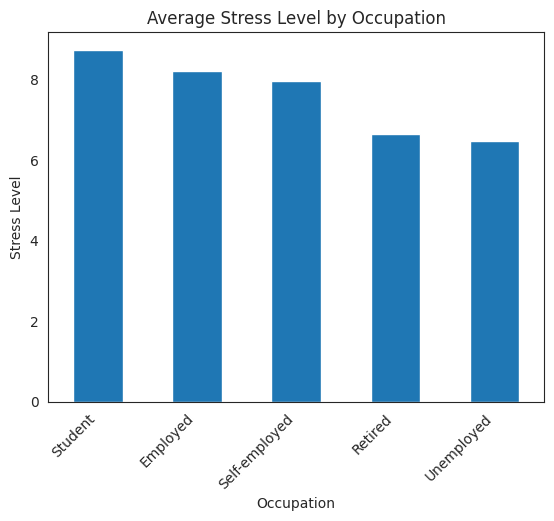

In [ ]:
stress_by_occ.plot(kind='bar')
plt.title("Average Stress Level by Occupation")
plt.ylabel("Stress Level")
plt.xlabel("Occupation")
plt.xticks(rotation=45, ha='right')
plt.show()

Students exhibit the highest average stress levels compared to other occupational groups. This may be attributed to academic pressure and irregular lifestyle patterns. In contrast, retired individuals show significantly lower stress levels.

**Stress Level of Employed People based on Work Mode - ( Remote, In-person, hybrid)**

In [ ]:
df_emp = df[df['occupation'] == 'Employed']

In [ ]:
#Group By work-mode

stress_by_workmode = df_emp.groupby('work_mode')['stress_level_0_10'].mean().sort_values(ascending=False)

print(stress_by_workmode)

work_mode
Remote       8.675000
Hybrid       8.097872
In-person    7.954386
Name: stress_level_0_10, dtype: float64


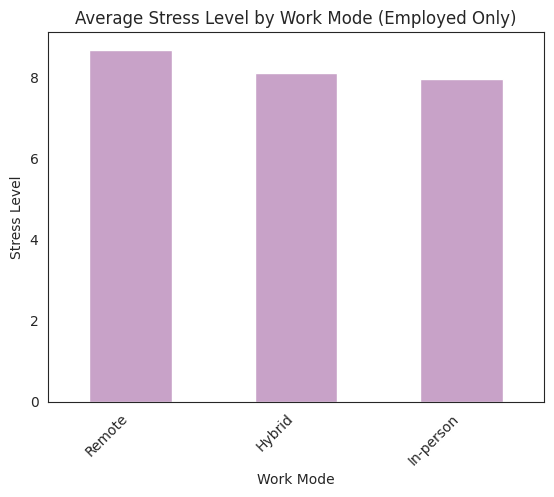

In [ ]:
stress_by_workmode.plot(kind='bar', color='#C8A2C8')

plt.title("Average Stress Level by Work Mode (Employed Only)")
plt.ylabel("Stress Level")
plt.xlabel("Work Mode")
plt.xticks(rotation=45, ha='right')

#plt.tight_layout()
plt.show()

## Behavioral Clustering Analysis

Objective is to identify latent behavioral profiles among users. By analyzing
combined patterns of screen time, sleep, productivity and stress, clustering techniques are applied to detect natural groupings within the data. Behavioral clustering analysis was conducted to identify distinct groups of individuals based on their digital and
lifestyle patterns.

In [ ]:
features = [
    'screen_time_hours',
    'work_screen_hours',
    'leisure_screen_hours',
    'sleep_hours',
    'exercise_minutes_per_week',
    'social_hours_per_week'
]

X_cluster = df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Find optimal number of clusters (Elbow method)

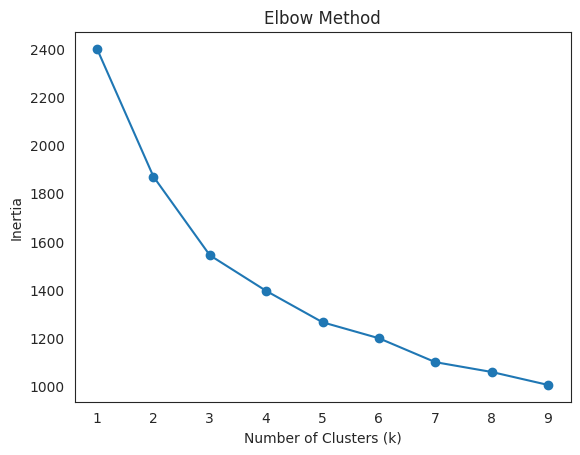

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Apply K-means**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

A. Mean behavior per cluster

In [ ]:
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

         screen_time_hours  work_screen_hours  leisure_screen_hours  \
cluster                                                               
0                10.843068           5.243068              5.600000   
1                 6.854136           1.245679              5.608457   
2                10.302667           1.400267              8.902400   

         sleep_hours  exercise_minutes_per_week  social_hours_per_week  
cluster                                                                 
0           6.841591                  98.511364               7.432955  
1           7.510679                 136.506173               9.028395  
2           6.576533                  87.606667               6.968667  


Stress per cluster

In [ ]:
stress_cluster = df.groupby('cluster')['stress_level_0_10'].mean()
print(stress_cluster)

cluster
0    9.164773
1    6.637037
2    9.190000
Name: stress_level_0_10, dtype: float64


Visualize clusters

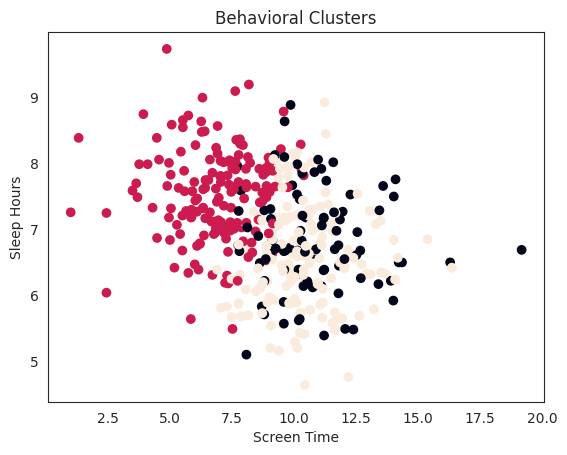

In [ ]:
plt.scatter(df['screen_time_hours'], df['sleep_hours'], c=df['cluster'])
plt.xlabel("Screen Time")
plt.ylabel("Sleep Hours")
plt.title("Behavioral Clusters")
plt.show()

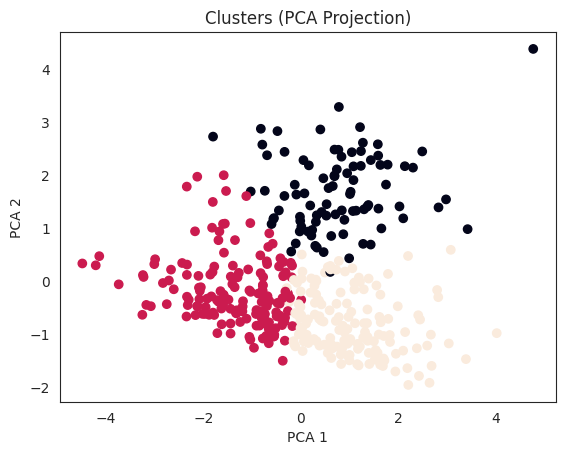

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters (PCA Projection)")
plt.show()

In [ ]:
df.groupby('cluster')['stress_level_0_10'].mean()

,stress_level_0_10
cluster,
0,9.164773
1,6.637037
2,9.190000


Cluster -------- Label

0 -------------- Work-Oriented Users

1 -------------- Healthy & Balanced Users

2 -------------- High Leisure / High-Risk Users




Three behavioral clusters were identified using K-Means clustering. Cluster 1 represents a balanced lifestyle group characterized by lower screen time, higher sleep duration, and greater physical and social activity. Cluster 2 shows a high leisure screen usage pattern with reduced sleep and physical activity, indicating a potentially high-risk group for stress. Cluster 0 represents work-oriented users with high screen exposure primarily driven by occupational demands.

DBSCAN Clustering

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts())

dbscan_cluster
-1    344
 0     16
 1     16
 2      9
 5      6
 3      5
 4      4
Name: count, dtype: int64


In [ ]:
df.groupby('dbscan_cluster')[features].mean()

,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,exercise_minutes_per_week,social_hours_per_week
dbscan_cluster,,,,,,
-1,9.030930,2.383401,6.647529,7.007006,112.337209,7.891860
0,9.747500,0.798125,8.949375,6.501875,84.687500,6.725000
1,7.843750,1.348125,6.495625,7.326250,160.562500,8.731250
2,7.996667,0.905556,7.091111,7.043333,79.222222,11.433333
3,10.824000,0.888000,9.936000,7.162000,54.400000,6.480000
4,10.222500,0.637500,9.585000,6.730000,31.250000,0.175000
5,9.146667,0.643333,8.503333,7.915000,41.000000,10.650000


Analyze stress per cluster

In [ ]:
df.groupby('dbscan_cluster')['stress_level_0_10'].mean()

,stress_level_0_10
dbscan_cluster,
-1,8.068023
0,9.162500
1,7.637500
2,8.933333
3,9.380000
4,9.250000
5,8.616667


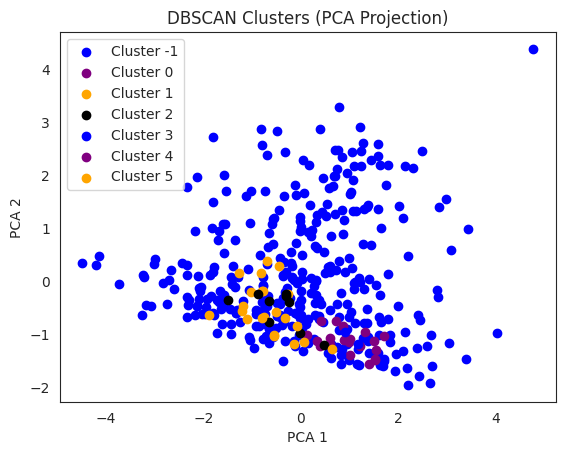

In [ ]:
unique_clusters = np.unique(df['dbscan_cluster'])

# Define fixed colors
colors = ['blue','purple', 'orange', 'black']

color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

for cluster in unique_clusters:
    mask = df['dbscan_cluster'] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=color_map[cluster],
        label=f"Cluster {cluster}"
    )

plt.legend()
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
for eps in [0.6, 0.7, 0.8, 1, 1.5]:
    for min_s in [3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        print(f"eps={eps}, min_samples={min_s}, clusters={set(labels)}")

eps=0.6, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(-1)}
eps=0.6, min_samples=4, clusters={np.int64(0), np.int64(-1)}
eps=0.6, min_samples=5, clusters={np.int64(-1)}
eps=0.7, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(-1)}
eps=0.7, min_samples=4, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}
eps=0.7, min_samples=5, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.8, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), n

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

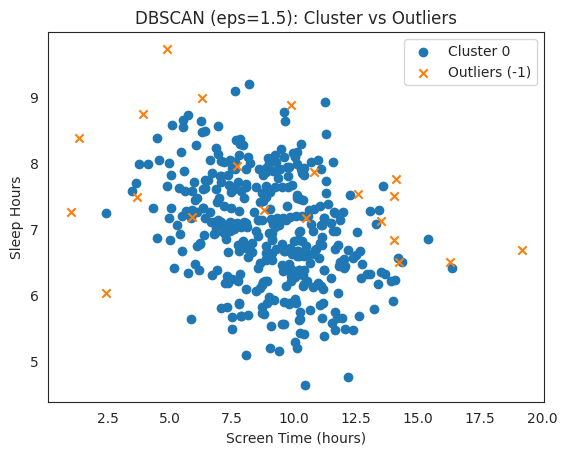

In [ ]:

# Main cluster
cluster0 = df[df['dbscan_cluster'] == 0]
plt.scatter(cluster0['screen_time_hours'], cluster0['sleep_hours'], label='Cluster 0')

# Outliers
outliers = df[df['dbscan_cluster'] == -1]
plt.scatter(outliers['screen_time_hours'], outliers['sleep_hours'],
            marker='x', label='Outliers (-1)')

plt.xlabel("Screen Time (hours)")
plt.ylabel("Sleep Hours")
plt.title("DBSCAN (eps=1.5): Cluster vs Outliers")

plt.legend()
plt.show()

**Applying PCA**

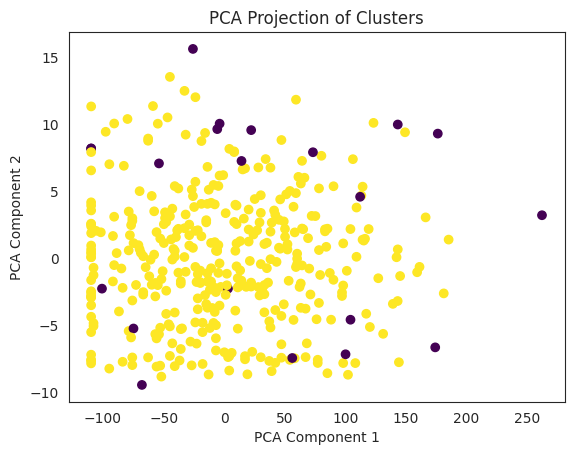

In [ ]:
features = [
    'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours',
    'sleep_hours', 'exercise_minutes_per_week', 'social_hours_per_week'
]
X = df[features]

# PCA projection to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=df['dbscan_cluster'], cmap='viridis', label='Cluster')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Clusters")
plt.show()

**Applying t-sne**

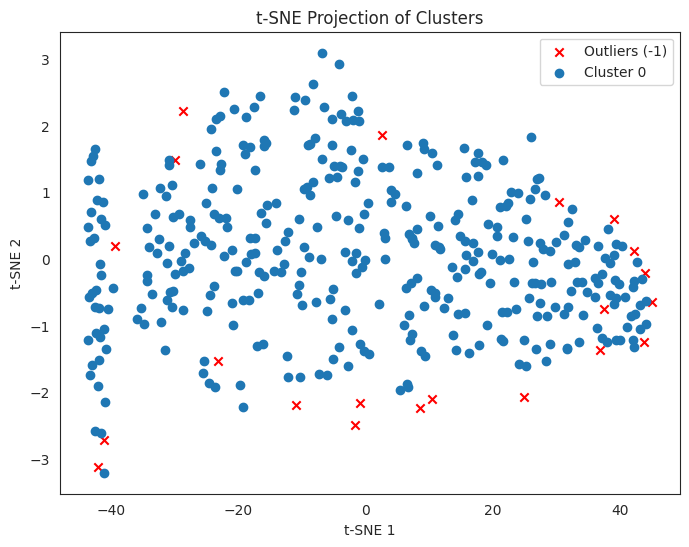

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

# Use cluster labels from your DBSCAN or K-Means
clusters = df['dbscan_cluster']

# Plot each cluster
for cluster_label in sorted(clusters.unique()):
    idx = clusters == cluster_label
    if cluster_label == -1:
        # Outliers
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    marker='x', label=f'Outliers ({cluster_label})', color='red')
    else:
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    label=f'Cluster {cluster_label}')

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Clusters")
plt.legend()
plt.show()

DBSCAN sucessfully detects outliers, identifying individuals
with extreme behavioral patterns that may not belong to any cluster.